In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/churn_dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,tenure_months,monthly_charges,support_calls,contract_type,churned
0,52,105.57,2,Month-to-month,1
1,15,103.02,3,Month-to-month,1
2,61,59.72,2,One year,1
3,21,86.81,0,Month-to-month,1
4,24,40.50,1,Two year,1


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure_months    1000 non-null   int64  
 1   monthly_charges  1000 non-null   float64
 2   support_calls    1000 non-null   int64  
 3   contract_type    1000 non-null   object 
 4   churned          1000 non-null   int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 39.2+ KB


In [ ]:
df.shape

(1000, 5)

In [ ]:
print(df['churned'].value_counts())
df.describe()

churned
1    691
0    309
Name: count, dtype: int64


,tenure_months,monthly_charges,support_calls,churned
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.489000,70.515320,1.499000,0.691000
std,20.709485,29.311928,1.241588,0.462312
min,1.000000,20.490000,0.000000,0.000000
25%,17.000000,44.032500,1.000000,0.000000
50%,35.000000,71.805000,1.000000,1.000000
75%,54.000000,96.047500,2.000000,1.000000
max,71.000000,119.940000,7.000000,1.000000


In [ ]:
df['contract_type'].value_counts()

,count
contract_type,
Month-to-month,568
One year,231
Two year,201


In [ ]:
df.groupby('contract_type')['churned'].mean()

,churned
contract_type,
Month-to-month,0.799296
One year,0.623377
Two year,0.462687


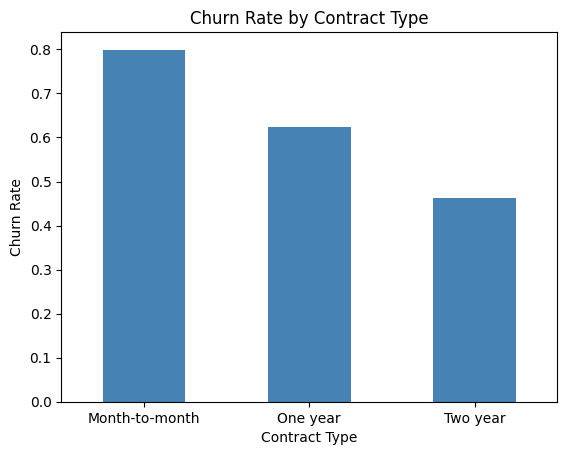

In [ ]:
import matplotlib.pyplot as plt

df.groupby('contract_type')['churned'].mean().plot(kind='bar', color='steelblue')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.show()

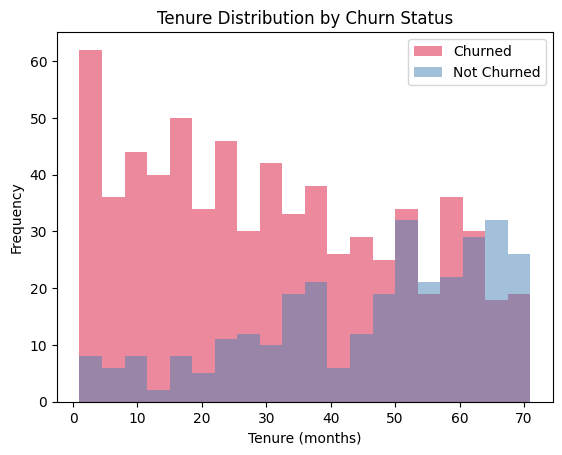

In [ ]:
df[df['churned']==1]['tenure_months'].plot(kind='hist', alpha=0.5, label='Churned', bins=20, color='crimson')
df[df['churned']==0]['tenure_months'].plot(kind='hist', alpha=0.5, label='Not Churned', bins=20, color='steelblue')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (months)')
plt.legend()
plt.show()

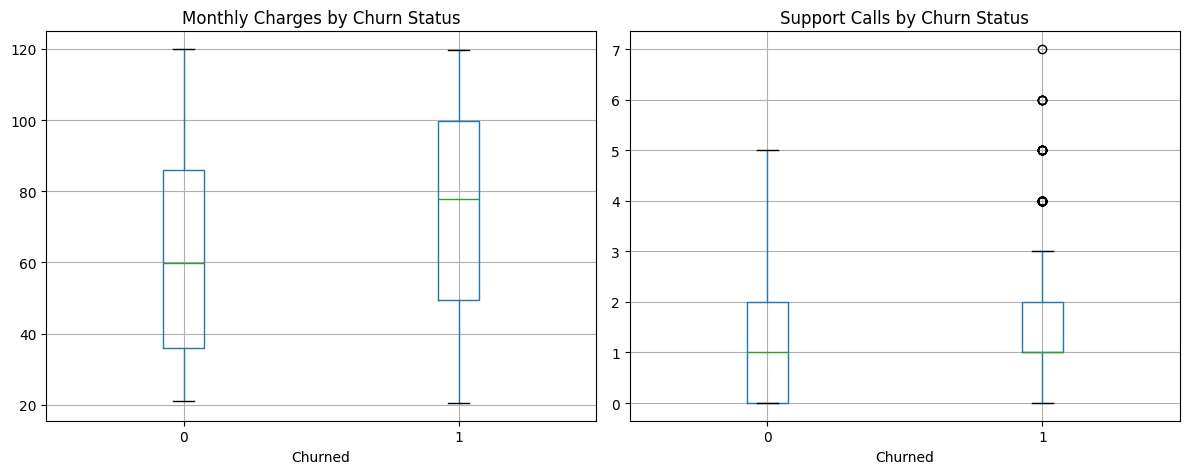

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='monthly_charges', by='churned', ax=axes[0])
axes[0].set_title('Monthly Charges by Churn Status')
axes[0].set_xlabel('Churned')

df.boxplot(column='support_calls', by='churned', ax=axes[1])
axes[1].set_title('Support Calls by Churn Status')
axes[1].set_xlabel('Churned')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
df_encoded = pd.get_dummies(df, columns=['contract_type'], drop_first=True)
df_encoded.head()

,tenure_months,monthly_charges,support_calls,churned,contract_type_One year,contract_type_Two year
0,52,105.57,2,1,False,False
1,15,103.02,3,1,False,False
2,61,59.72,2,1,True,False
3,21,86.81,0,1,False,False
4,24,40.50,1,1,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('churned', axis=1)
y = df_encoded['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(800, 5)
(200, 5)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7400


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 31  34]
 [ 18 117]]
              precision    recall  f1-score   support

           0       0.63      0.48      0.54        65
           1       0.77      0.87      0.82       135

    accuracy                           0.74       200
   macro avg       0.70      0.67      0.68       200
weighted avg       0.73      0.74      0.73       200



In [ ]:
import pandas as pd

coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print(coefficients)

                  feature  coefficient
2           support_calls     0.299409
1         monthly_charges     0.019766
0           tenure_months    -0.051089
3  contract_type_One year    -1.145645
4  contract_type_Two year    -2.038789


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

Random Forest Accuracy: 0.7450


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

[[ 29  36]
 [ 15 120]]
              precision    recall  f1-score   support

           0       0.66      0.45      0.53        65
           1       0.77      0.89      0.82       135

    accuracy                           0.74       200
   macro avg       0.71      0.67      0.68       200
weighted avg       0.73      0.74      0.73       200

                  feature  importance
1         monthly_charges    0.402301
0           tenure_months    0.387828
2           support_calls    0.100261
4  contract_type_Two year    0.071704
3  contract_type_One year    0.037906
